# ***Give Me Some Credit*: Model comparison. Ewaluacja 8 pipeline'ów na zbiorze testowym**

Niniejszy notebook stanowi wizualne uzupełnienie sekcji *Final Evaluation* oraz *Hyperparameter Tuning* dokumentu README - prezentuje te same wyniki liczbowe w formie wykresów, zamiast tabel tekstowych. Wszystkie wartości obliczane są bezpośrednio na podstawie zawartych w repozytorium artefaktów (`src/ml/artifacts/*.joblib`) oraz tego samego, 30-tysięcznego zbioru testowego wykorzystanego w ewaluacji końcowej - żadna z prezentowanych wartości nie została przepisana ręcznie z dokumentacji.

**Uwaga metodologiczna.** Analiza przeprowadzona w niniejszym notebooku stanowi kolejny (po `final_evaluation.py` oraz `fairness_audit.py`) świadomy, wyłącznie odczytowy dostęp do zbioru testowego. Nie stanowi to naruszenia przyjętej w projekcie zasady jednokrotnego wykorzystania zbioru testowego do celów selekcji modelu - żadna z przedstawionych poniżej analiz nie wpływa na wybór modelu ani dobór hiperparametrów; wszystkie decyzje modelowe zostały podjęte i zatwierdzone przed przystąpieniem do niniejszej analizy. Pełne uzasadnienie tego rozróżnienia znajduje się w README, w sekcji Fairness Audit.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from ml.config import ARTIFACTS_DIR
from ml.data.loader import load_and_split, split_X_y
from ml.evaluation.final_evaluation import MODEL_NAMES
from ml.models.mlp import TorchMLPClassifier  # noqa: F401 - needed to unpickle the MLP pipeline

BLUE = "#2a78d6"
ORANGE = "#eb6834"
RED = "#e34948"
GOOD = "#0ca30c"
CRITICAL = "#d03b3b"
PRIMARY_INK = "#0b0b0b"
MUTED_INK = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

BLUE_SEQ = LinearSegmentedColormap.from_list("blue_seq", [SURFACE, BLUE])

# Fixed order, never cycled - same 8-model order as MODEL_NAMES everywhere else in this
# project. Linear models share a blue family, tree models a green family, XGBoost keeps
# the README's orange (it's the overall winner), Naive Bayes and MLP get their own hues
# since neither shares a family with anything else here.
MODEL_COLORS = {
    "logistic_regression": "#2a78d6",
    "linear_svm": "#6fa8e0",
    "rbf_svm": "#7d5ba6",
    "random_forest": "#0ca30c",
    "decision_tree": "#8fc93f",
    "xgboost": "#eb6834",
    "naive_bayes": "#d6a72a",
    "mlp": "#c2478a",
}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": PRIMARY_INK,
    "text.color": PRIMARY_INK,
    "xtick.color": MUTED_INK,
    "ytick.color": MUTED_INK,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

pd.set_option("display.max_columns", None)

### **Wczytanie artefaktów oraz generowanie predykcji na zbiorze testowym**

Każdy z 8 zapisanych pipeline'ów (struktura: czyszczenie danych → inżynieria cech → opcjonalne skalowanie → model, zgodnie z opisem zamieszczonym w sekcji API dokumentu README) zostaje wczytany z dysku i poddany jednokrotnej ewaluacji na tym samym zbiorze 30 000 obserwacji testowych.

Należy zaznaczyć, że klasyfikatory `LinearSVC` oraz `SVC` z jądrem RBF nie udostępniają metody `predict_proba` - w ich przypadku wykorzystywana jest metoda `decision_function`. Dla potrzeb wyznaczenia krzywych ROC oraz Precision-Recall rozróżnienie to pozostaje bez znaczenia: obie miary są niezmiennicze względem monotonicznych przekształceń wyniku klasyfikatora, wobec czego surowa wartość marginesu decyzyjnego prowadzi do identycznej
wartości pola pod krzywą (AUC), jak jakakolwiek jej kalibracja probabilistyczna. Sytuacja ta odróżnia się od implementacji endpointu `/predict` w warstwie API, który zobowiązany jest zwrócić wartość z przedziału (0, 1) i w tym celu stosuje transformację sigmoidalną (por. README, sekcja API, funkcja `_score()`).

In [2]:
_train_df, test_df = load_and_split()
X_test, y_test = split_X_y(test_df)

results = {}
for name in MODEL_NAMES:
    pipeline = joblib.load(ARTIFACTS_DIR / f"{name}.joblib")
    y_pred = pipeline.predict(X_test)
    y_score = (
        pipeline.predict_proba(X_test)[:, 1]
        if hasattr(pipeline, "predict_proba")
        else pipeline.decision_function(X_test)
    )
    results[name] = {"y_pred": y_pred, "y_score": y_score}

print(f"Zbiór testowy: {len(y_test):,} wierszy, {y_test.mean():.1%} rzeczywistego default")

Zbiór testowy: 30,000 wierszy, 6.7% rzeczywistego default


## **Tabela zbiorcza metryk**

Poniższa tabela przedstawia komplet metryk klasyfikacyjnych obliczonych na zbiorze testowym, uszeregowanych malejąco względem wartości PR-AUC - metryki przyjętej w niniejszym projekcie jako podstawowe kryterium oceny jakości modeli (uzasadnienie wyboru: README, sekcja "Why not accuracy"). Wartość ROC-AUC obliczono dodatkowo na potrzeby niniejszego zestawienia; nie jest ona śledzona w systemie MLflow ani przechowywana w bazie danych. W
przypadku zbioru silnie niezbalansowanego, jakim jest analizowany zbiór danych (ok. 6.7% obserwacji klasy pozytywnej), metryka ROC-AUC wykazuje tendencję do systematycznego zawyżania oceny jakości modelu - liczna reprezentacja prawdziwych negatywów w mianowniku współczynnika *False Positive Rate* skutkuje jego niską wartością nawet przy relatywnie dużej liczbie fałszywych alarmów w wartościach bezwzględnych. Sama rozbieżność między wartościami obu metryk stanowi zatem istotną obserwację samą w sobie.

In [3]:
rows = []
for name in MODEL_NAMES:
    y_pred = results[name]["y_pred"]
    y_score = results[name]["y_score"]
    rows.append(
        {
            "model": name,
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "pr_auc": average_precision_score(y_test, y_score),
            "roc_auc": roc_auc_score(y_test, y_score),
            "accuracy": accuracy_score(y_test, y_pred),
        }
    )

stats_df = pd.DataFrame(rows).set_index("model").sort_values("pr_auc", ascending=False)
model_order = stats_df.index.tolist()
stats_df.style.background_gradient(subset=["pr_auc", "roc_auc"], cmap=BLUE_SEQ).format(precision=3)

,precision,recall,f1,pr_auc,roc_auc,accuracy
model,,,,,,
xgboost,0.217,0.787,0.340,0.404,0.870,0.796
random_forest,0.232,0.754,0.355,0.401,0.867,0.817
mlp,0.210,0.788,0.332,0.398,0.866,0.788
logistic_regression,0.215,0.770,0.336,0.393,0.863,0.796
linear_svm,0.202,0.788,0.321,0.388,0.863,0.777
decision_tree,0.206,0.781,0.326,0.370,0.855,0.784
rbf_svm,0.225,0.681,0.339,0.369,0.857,0.822
naive_bayes,0.344,0.544,0.421,0.355,0.850,0.900


## **Porównanie metryk klasyfikacyjnych**

Poniższy wykres słupkowy przedstawia pięć podstawowych metryk klasyfikacyjnych (*precision*, *recall*, *F1 score*, *PR-AUC* oraz *accuraccy*) w układzie grupowanym według metryki, z modelami uszeregowanymi zgodnie z kolejnością ustaloną w tabeli powyżej (malejąco względem wartości PR-AUC).

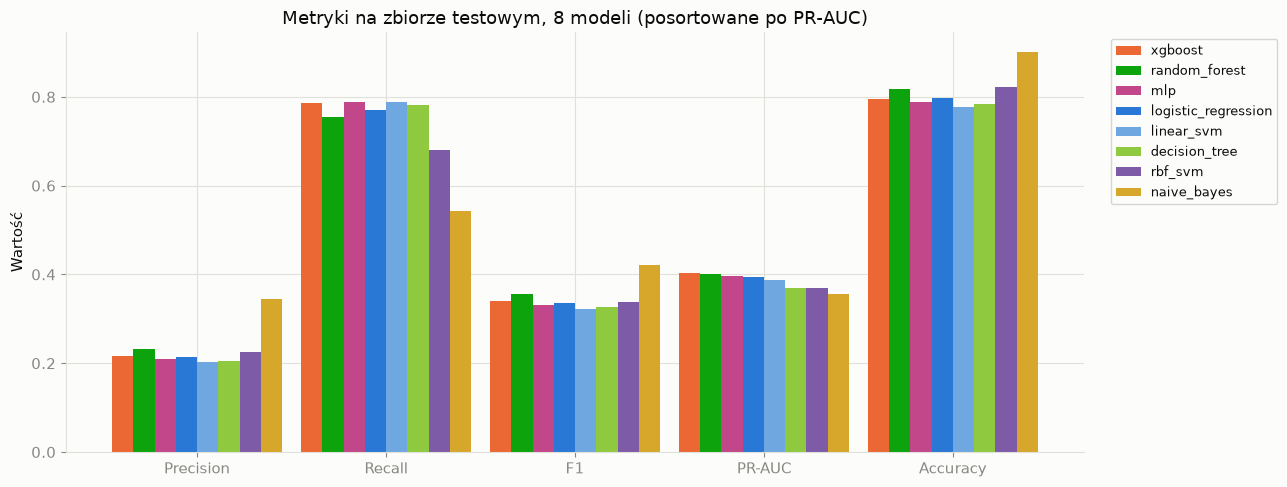

In [4]:
metrics_to_plot = ["precision", "recall", "f1", "pr_auc", "accuracy"]

fig, ax = plt.subplots(figsize=(13, 5))
n_models = len(model_order)
bar_width = 0.9 / n_models
x = np.arange(len(metrics_to_plot))

for i, name in enumerate(model_order):
    values = stats_df.loc[name, metrics_to_plot].to_numpy(dtype=float)
    ax.bar(x + i * bar_width, values, width=bar_width, label=name, color=MODEL_COLORS[name])

ax.set_xticks(x + bar_width * (n_models - 1) / 2)
ax.set_xticklabels(["Precision", "Recall", "F1", "PR-AUC", "Accuracy"])
ax.set_ylabel("Wartość")
ax.set_title("Metryki na zbiorze testowym, 8 modeli (posortowane po PR-AUC)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()

## **Krzywe ROC (*Receiver Operating Characteristic*)**

Krzywa ROC przedstawia zależność między odsetkiem prawdziwie pozytywnych klasyfikacji (True Positive Rate) a odsetkiem fałszywie pozytywnych klasyfikacji (False Positive Rate), wyznaczoną dla wszystkich możliwych progów decyzyjnych. Wszystkie 8 modeli zestawiono na jednym wykresie; linia przerywana odpowiada klasyfikatorowi losowemu (AUC = 0,5).

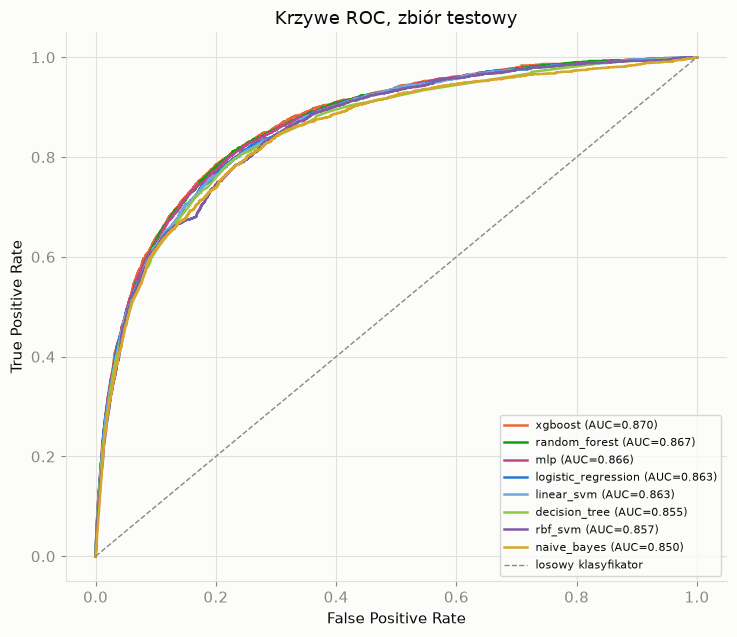

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name in model_order:
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_score"])
    auc = stats_df.loc[name, "roc_auc"]
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], label=f"{name} (AUC={auc:.3f})", linewidth=1.8)

ax.plot([0, 1], [0, 1], color=MUTED_INK, linestyle="--", linewidth=1, label="losowy klasyfikator")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Krzywe ROC, zbiór testowy")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()

## **Krzywe Precision-Recall**

Przy udziale klasy pozytywnej wynoszącym ok. 6,7% krzywa Precision-Recall dostarcza
istotnie więcej informacji diagnostycznej niż krzywa ROC (uzasadnienie: README, sekcja "Why
not accuracy") - duża liczba prawdziwych negatywów sprawia, że krzywa ROC prezentuje
korzystny obraz jakości modelu nawet w przypadku relatywnie słabej precyzji predykcji.
Linią przerywaną oznaczono poziom bazowy odpowiadający klasyfikatorowi losowemu, który w
tym przypadku odpowiada częstości występowania klasy pozytywnej w zbiorze testowym (ok.
6,7%), nie wartości 0,5, jak ma to miejsce w przypadku krzywej ROC.

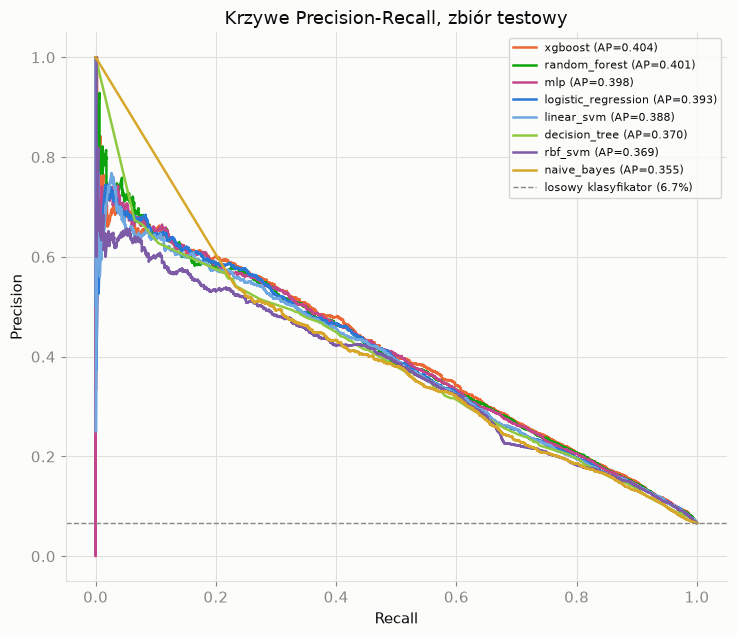

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
prevalence = y_test.mean()
for name in model_order:
    precision, recall, _ = precision_recall_curve(y_test, results[name]["y_score"])
    ap = stats_df.loc[name, "pr_auc"]
    ax.plot(recall, precision, color=MODEL_COLORS[name], label=f"{name} (AP={ap:.3f})", linewidth=1.8)

ax.axhline(
    prevalence, color=MUTED_INK, linestyle="--", linewidth=1, label=f"losowy klasyfikator ({prevalence:.1%})"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Krzywe Precision-Recall, zbiór testowy")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()

## **Macierze pomyłek (*Confusion Matrices*)**

Prezentowane macierze pomyłek zostały znormalizowane wierszowo (względem rzeczywistej
klasy) - przy proporcji klas wynoszącej ok. 93,3%/6,7% zastosowanie wartości bezwzględnych
skutkowałoby zdominowaniem wizualizacji przez jedną komórkę, praktycznie uniemożliwiając
odczyt pozostałych wartości. Górny wiersz każdej macierzy odpowiada rzeczywistemu brakowi
zdarzenia default, dolny wiersz - jego wystąpieniu.

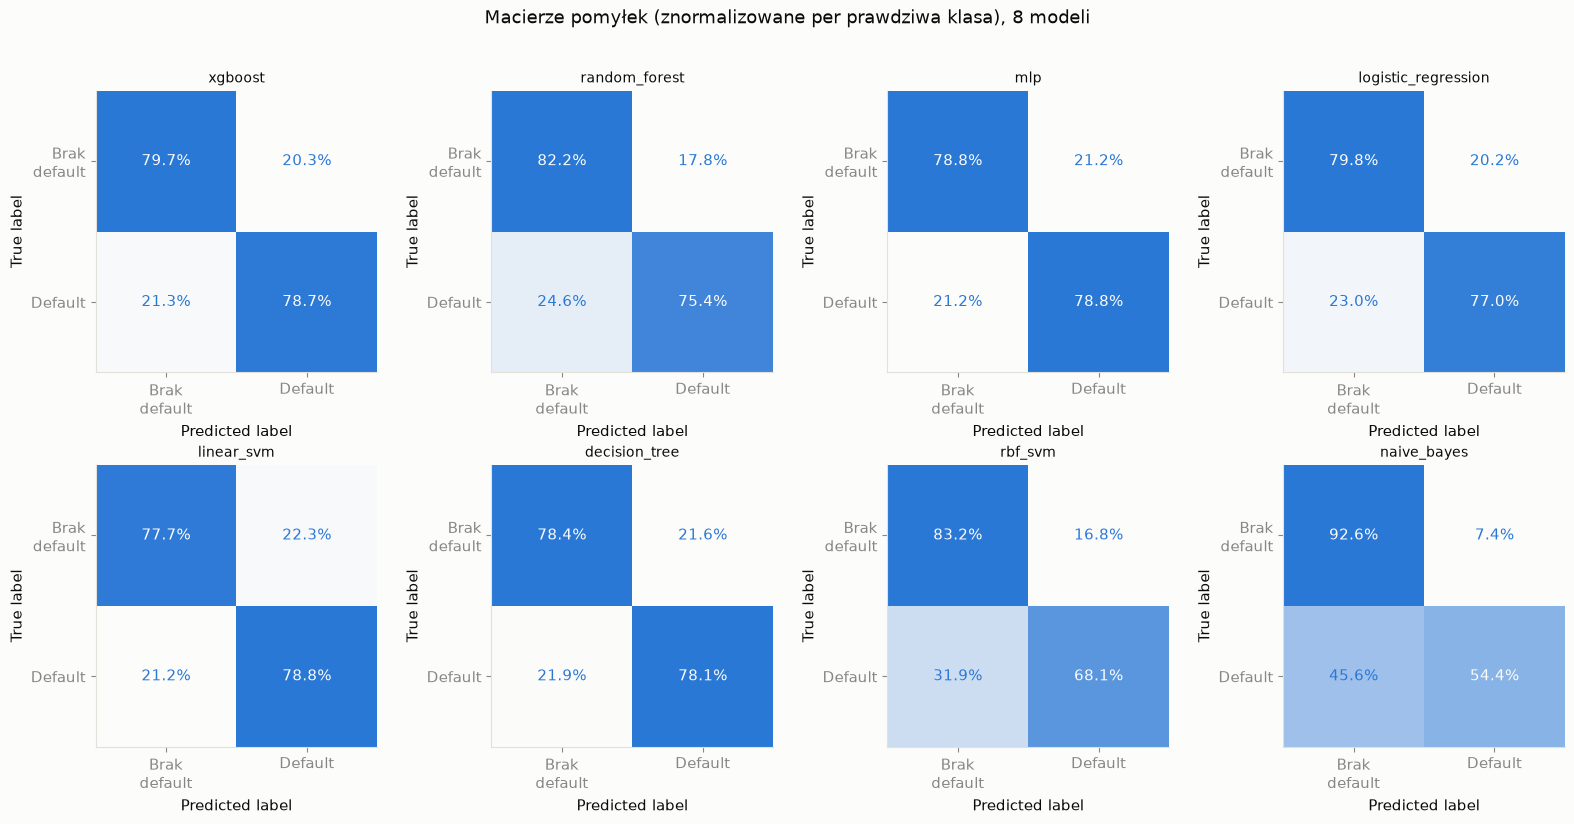

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, name in zip(axes.flat, model_order):
    cm = confusion_matrix(y_test, results[name]["y_pred"], normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=["Brak\ndefaultu", "Default"])
    disp.plot(ax=ax, cmap=BLUE_SEQ, colorbar=False, values_format=".1%")
    ax.set_title(name, fontsize=10)
    ax.grid(False)

plt.suptitle("Macierze pomyłek (znormalizowane per prawdziwa klasa), 8 modeli", y=1.02, fontsize=13)
plt.tight_layout()

## **Porównanie PR-AUC: walidacja krzyżowa a zbiór testowy**

Proces strojenia hiperparametrów (30 prób Optuna na model) opierał się wyłącznie na wyniku walidacji krzyżowej (CV) - zbiór testowy nie był w żadnym momencie tego procesu wykorzystywany do podejmowania decyzji modelowych. Systematycznie niższa wartość PR-AUC na zbiorze testowym względem estymaty uzyskanej w walidacji krzyżowej stanowiłaby przesłankę wskazującą na przeuczenie się procesu strojenia do foldów walidacyjnych (*optimizer's curse*). Poniższa komórka odczytuje wartości CV PR-AUC z lokalnej bazy `mlflow.db` (plik celowo nieobjęty repozytorium) - w przypadku jej braku (np. świeżo sklonowane repozytorium bez uprzednio uruchomionego `tune.py`) wykres zostaje pominięty, a w jego miejsce wyświetlony zostaje odpowiedni komunikat diagnostyczny.

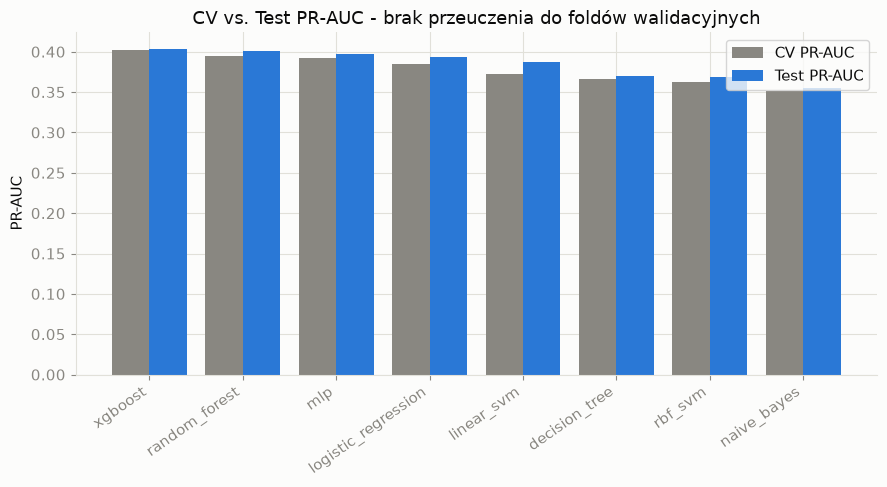

In [8]:
try:
    import mlflow

    from ml.tracking.mlflow_utils import configure_mlflow

    configure_mlflow()
    cv_pr_auc = {}
    for name in MODEL_NAMES:
        runs = mlflow.search_runs(
            filter_string=f"tags.model_name = '{name}' and tags.stage = 'tuned'", output_format="pandas"
        )
        if len(runs) == 0:
            raise ValueError("brak tuned runs - lokalny mlflow.db jest pusty lub nie istnieje")
        cv_pr_auc[name] = runs.iloc[0]["metrics.pr_auc_mean"]

    gap_df = pd.DataFrame({"cv_pr_auc": cv_pr_auc, "test_pr_auc": stats_df["pr_auc"]}).loc[model_order]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(model_order))
    ax.bar(x - 0.2, gap_df["cv_pr_auc"], width=0.4, label="CV PR-AUC", color=MUTED_INK)
    ax.bar(x + 0.2, gap_df["test_pr_auc"], width=0.4, label="Test PR-AUC", color=BLUE)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right")
    ax.set_ylabel("PR-AUC")
    ax.set_title("CV vs. Test PR-AUC - brak przeuczenia do foldów walidacyjnych")
    ax.legend()
    plt.tight_layout()
except Exception as e:
    print(f"Pominięto: {e}")
    print("Ten wykres wymaga lokalnego `python -m ml.training.tune` - patrz README, Hyperparameter Tuning.")

## **Wnioski**

- **XGBoost osiąga najwyższą wartość PR-AUC** (metryka podstawowa w niniejszym projekcie), jednak jego przewaga nad Random Forest jest wyraźnie mniejsza, niż sugerowałaby różnica w wartościach ROC-AUC. Obserwacja ta potwierdza tezę opisaną w README (*Why not accuracy*): metryka ROC-AUC systematycznie zaciera różnice między modelami przy tak silnie niezbalansowanym zbiorze danych.
- **Naive Bayes osiąga najniższą wartość PR-AUC przy jednocześnie relatywnie wysokiej wartości F1.** Zjawisko to znajduje bezpośrednie potwierdzenie w macierzy pomyłek: wysoka czułość (*recall*) uzyskiwana jest kosztem znacznej liczby fałszywych alarmów. Krzywa Precision-Recall ujawnia tę zależność precyzyjniej niż pojedyncza wartość F1 - krzywa Naive Bayes rozpoczyna się na wysokim poziomie precyzji, lecz opada szybciej niż krzywe modeli drzewiastych.
- **RBF SVM oraz Linear SVM**, mimo braku metody `predict_proba`, generują krzywe ROC oraz Precision-Recall w pełni porównywalne z pozostałymi modelami - wyznaczenie pola pod krzywą nie wymaga skalibrowanego prawdopodobieństwa, a jedynie poprawnego uporządkowania obserwacji względem wyniku klasyfikatora (por. komórka wczytania modeli powyżej).